#### **Imports**

In [14]:
import sys
sys.path.append("../")

from dataset.data_classes import PytorchSpectraDataset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
import joblib
import torch
from tqdm import tqdm
import numpy as np
import math
import contextlib
import io
import random
import pandas as pd
from sklearn.manifold import TSNE

from models.cbegan_lightning import SpectralCBEGAN
from models.cvae_lightning import LitVAE
from models.cdiff_lightning import LitCfgDiffusion

from utils.utils import encode_labels, load_config
from utils.experiments import generate_batch_spectra

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score

from imblearn.over_sampling import SMOTENC, RandomOverSampler

import warnings

#### **Data Prep**

In [15]:
dataset = PytorchSpectraDataset("../data/h4h_raw_2024-09-16_with_subject_ids.parquet")
df = dataset.df_train_scaled

minmax_scaler = dataset.min_max_scaler

age_bmi_orig = minmax_scaler.inverse_transform(df[["age", "bmi"]])
df["age_orig"] = age_bmi_orig[:, 0]
df["bmi_orig"] = age_bmi_orig[:, 1]

df = PytorchSpectraDataset.create_single_visit_cohorts(dataset, df)
df = PytorchSpectraDataset.rebalance_single_visit_cohorts(dataset, df)
df = df.reset_index(drop=True)

In [16]:
df.head(2)

,1000.88098144531,1002.80944824219,1004.73791503906,1006.66638183594,1008.59484863281,1010.52337646484,1012.45184326172,1014.38031005859,1016.30877685547,1018.23724365234,...,2996.857421875,2998.78588867188,subject_id,sample_id,age,sex,bmi,test_set,age_orig,bmi_orig
0,-0.530498,-0.505044,-0.460960,-0.369351,-0.306335,-0.256232,-0.219883,-0.263876,-0.317633,-0.297464,...,-0.592275,-0.615778,H4H_16_0123,C_0008209,0.177778,0,0.281928,2,47.0,27.34
1,0.501051,0.432946,0.404894,0.334264,0.255708,0.214922,0.172017,0.135171,0.063924,-0.090906,...,0.507107,0.531094,H4H_14_0401,C_0010423,0.022222,1,0.227782,1,40.0,24.97


#### **Define functions**

In [17]:
def column_to_class(values: np.ndarray, thresholds: np.ndarray) -> np.ndarray:
    # Ensure thresholds are sorted
    thresholds = np.sort(thresholds)
    # np.searchsorted returns the index where each value would be inserted
    return np.searchsorted(thresholds, values, side='right')

In [18]:
def plot_confusion_matrix(cm, class_names, method_name, auc, mae):
    """Plots a styled confusion matrix."""
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    fig.colorbar(im, ax=ax)
    
    ax.set(
        xticks=np.arange(cm.shape[1]),
        yticks=np.arange(cm.shape[0]),
        xticklabels=class_names,
        yticklabels=class_names,
        title=f'{method_name}\nAUC: {auc:.3f} | MAE: {mae:.2f}',
        ylabel="True Label",
        xlabel="Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = ".2f" if cm.dtype == float else "d"
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], fmt),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )
    fig.tight_layout()
    plt.show()
    
def weighted_sum(matrix):
    """Calculates the Mean Absolute Error from a confusion matrix."""
    n = matrix.shape[0]
    total_error = 0
    total_samples = np.sum(matrix)
    for i in range(n):
        for j in range(n):
            total_error += matrix[i][j] * abs(i - j)
    return total_error / total_samples if total_samples > 0 else 0

In [19]:
class DL_Oversampler():
    """
    """
    def __init__(self, model_name):
        self.model_name = model_name
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        if model_name == 'CBEGAN':
            self.model = SpectralCBEGAN.load_from_checkpoint(
                "../pretrained_models/weights_cbegan.ckpt", map_location=self.device
            )
        elif model_name == 'CVAE':
            checkpoint = torch.load(
                "../pretrained_models/weights_cvae.ckpt",
                weights_only=False,
                map_location=self.device
            )
            with contextlib.redirect_stdout(io.StringIO()):
                hparams = checkpoint['hyper_parameters']
                self.model = LitVAE(**hparams)
                self.model.load_state_dict(checkpoint['state_dict'])
        elif model_name == 'CDIFF':
            self.model = LitCfgDiffusion.load_from_checkpoint(
                "../pretrained_models/weights_cdiff.ckpt", map_location=self.device
            )
        else:
            raise ValueError("model_name must be in ['CBEGAN', 'CVAE', 'CDIFF']")

        self.model.eval()

    def resample(self, X, y, c, n='auto'):

        y_counts = pd.Series(y).value_counts()
        if y_counts.empty: return X, y, c
        majority_class_size = y_counts.max()
        unique_classes = y_counts.index.values

        X_all_new, y_all_new, c_all_new = [], [], []

        for k in unique_classes:
            if n == 'auto':
                n_samples_to_generate = majority_class_size - y_counts.get(k, 0)
                if n_samples_to_generate <= 0: continue
            else:
                n_samples_to_generate = sum(y == k)

            c_for_k = c[y == k].reset_index(drop=True)
            X_for_k = X[y == k].reset_index(drop=True)
            if c_for_k.empty or X_for_k.empty: continue

            # Build labels_df by tiling/sampling the real conditions to cover n_samples_to_generate
            # Shuffle age and bmi independently to create new combinations, matching old behaviour
            n_real = len(c_for_k)
            n_repeats = int(np.ceil(n_samples_to_generate / n_real))
            
            labels_df = pd.concat([c_for_k] * n_repeats, ignore_index=True).iloc[:n_samples_to_generate]
            labels_df["age"] = labels_df["age"].sample(frac=1).reset_index(drop=True).values
            labels_df["bmi"] = labels_df["bmi"].sample(frac=1).reset_index(drop=True).values

            # Single batched call replaces the per-sample loop
            X_new_k_df = generate_batch_spectra(
                model=self.model,
                labels=labels_df,
                column_names=X.columns.tolist(),
                device=self.device,
            )

            X_all_new.append(X_new_k_df)
            c_all_new.append(labels_df.reset_index(drop=True))
            y_all_new.extend([k] * len(X_new_k_df))

        if not X_all_new: return X, y, c

        X_new_df = pd.concat(X_all_new, ignore_index=True)
        c_new_df = pd.concat(c_all_new, ignore_index=True)
        y_new_arr = np.array(y_all_new)

        if n == 'auto':
            X_hat = pd.concat([X, X_new_df], ignore_index=True)
            c_hat = pd.concat([c, c_new_df], ignore_index=True)
            y_hat = np.concatenate([y, y_new_arr])
            return X_hat, y_hat, c_hat
        else:
            return X_new_df, y_new_arr, c_new_df

#### **Last Data Step: Assign classes and Create balanced dataset**

In [20]:
TYPE_TO_ANALYSE = 'age'

In [21]:
dataset = PytorchSpectraDataset("../data/h4h_raw_2024-09-16_with_subject_ids.parquet")
df = dataset.df_train_scaled

minmax_scaler = dataset.min_max_scaler

age_bmi_orig = minmax_scaler.inverse_transform(df[["age", "bmi"]])
df["age_orig"] = age_bmi_orig[:, 0]
df["bmi_orig"] = age_bmi_orig[:, 1]

df = PytorchSpectraDataset.create_single_visit_cohorts(dataset, df)
df = PytorchSpectraDataset.rebalance_single_visit_cohorts(dataset, df)
df = df.reset_index(drop=True)

In [22]:
conditional_cols_scaled = ['age', 'sex', 'bmi'] 

bmi_thresholds = {'Normal': 25.0, 'Overweight': 30.0, 'Obese': 9999.9}
age_thresholds = {'Young': 49, 'Middle aged':55, 'Old': 999}
sex_thresholds = {'Male': 0, 'Female': 1}


if TYPE_TO_ANALYSE == 'age':
    thresholds = age_thresholds
    y_values = column_to_class(df['age_orig'].values, thresholds=list(age_thresholds.values()))

elif TYPE_TO_ANALYSE == 'bmi':
    thresholds = bmi_thresholds
    y_values = column_to_class(df['bmi_orig'].values, thresholds=list(bmi_thresholds.values()))

elif TYPE_TO_ANALYSE == 'sex':
    thresholds = sex_thresholds
    y_values = df['sex'].values

df['class'] = pd.Series(y_values, index=df.index)
class_names = list(thresholds.keys())
class_ids = list(range(len(class_names))) 

# Create a balanced dataset by undersampling to the smallest class size
min_class_size = df['class'].value_counts().min()
df = df.groupby('class', group_keys=False).apply(
    lambda x: x.sample(min_class_size, random_state=42)
)

# Prepare final variables for modeling
X = df[df.columns[:519]]
y = df['class']

# Final summary
print("--- Dataset Balancing Summary ---")
print("Class distribution in the balanced dataset:")
print(y.map(dict(enumerate(class_names))).value_counts())

--- Dataset Balancing Summary ---
Class distribution in the balanced dataset:
class
Young          5161
Middle aged    5161
Old            5161
Name: count, dtype: int64


/tmp/ipykernel_12665/2442356771.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('class', group_keys=False).apply(


#### **Run it**

In [23]:
FRACTION_TO_KEEP = 0.1
#models_to_test = ["Baseline", "None", "Random", "SMOTENC", "CBEGAN", "CVAE", "CDIFF"]
models_to_test = ["CDIFF"]

all_results = {}

for model_id, model_name in enumerate(models_to_test):
    print(f"\n=== Running experiments with {model_name} ===")
    
    final_results = {}
    temp_results = {}

    # Setup scenarios
    scenarios = ['Baseline']
    for name in class_names:
        scenarios.append(name)

    for s in scenarios:
        temp_results[s] = {'cm': [], 'auc': [], 'mae': [], 'acc': []}

    # --- Cross-Validation Loop ---
    for fold_id, fold_df in tqdm(df.groupby('test_set'), desc=f"CV Folds ({model_name})"):
        
        train_idx, test_idx = train_test_split(
            fold_df.index, test_size=0.2,
            stratify=fold_df['class'],
            random_state=42
        )

        X_train, X_test = X.loc[train_idx], X.loc[test_idx]
        y_train, y_test = y.loc[train_idx], y.loc[test_idx]

        def train_and_evaluate(X_tr, y_tr, X_te, y_te):
            clf = LogisticRegression(penalty='l2', C=10, max_iter=int(1e+6), random_state=42)
            clf.fit(X_tr, y_tr)
            y_pred = clf.predict(X_te)
            y_proba = clf.predict_proba(X_te)
            cm = confusion_matrix(y_te, y_pred, labels=class_ids, normalize='all')

            if len(list(set(y_te))) > 2:
                auc = roc_auc_score(y_te, y_proba, multi_class='ovr')  # FIXED
            else:
                auc = roc_auc_score(y_te, y_proba[:, 1])
            mae = weighted_sum(cm)
            acc = accuracy_score(y_te, y_pred)
            return {'cm': cm, 'auc': auc, 'mae': mae, 'acc': acc}

        # 1. BASELINE
        if model_name == "Baseline": #Calculate baseline only once
            baseline_metrics = train_and_evaluate(X_train, y_train, X_test, y_test)
            for metric in baseline_metrics:
                temp_results['Baseline'][metric].append(baseline_metrics[metric])

        # 2. UNDERSAMPLE + OVERSAMPLE
        else:
            for class_id, class_name in enumerate(class_names):
                keep_indices = y_train[y_train == class_id].index
                reduce_indices = y_train[y_train != class_id].index

                if len(reduce_indices) == 0:
                    continue

                num_to_keep = max(1, int(len(reduce_indices) * FRACTION_TO_KEEP))

                np.random.seed(42)
                reduced_sample_indices = np.random.choice(
                    reduce_indices, size=num_to_keep, replace=False
                )

                final_indices = keep_indices.union(pd.Index(reduced_sample_indices))

                X_train_reduced = X.loc[final_indices]
                y_train_reduced = y.loc[final_indices]

                # UNDERSAMPLED DATASETS
                if model_name in ['None', None, 'NONE']:
                    X_train_fixed = X_train_reduced
                    y_train_fixed = y_train_reduced

                # DL MODELS
                if model_name.upper() in ['CBEGAN', 'CVAE', 'CDIFF']:
                    dlo = DL_Oversampler(model_name)
                    conditions_reduced = df.loc[X_train_reduced.index][conditional_cols_scaled]
                    X_train_fixed, y_train_fixed, c_train_fixed = dlo.resample(
                        X_train_reduced, y_train_reduced.values, conditions_reduced
                    )

                # RANDOM OVERSAMPLING
                elif model_name.upper() == 'RANDOM':
                    rovs = RandomOverSampler()
                    X_train_fixed, y_train_fixed = rovs.fit_resample(X_train_reduced, y_train_reduced.values)
                    
                # SMOTENC
                elif model_name.upper() == 'SMOTENC':
                    smote_nc = SMOTENC(categorical_features=[0, 1, 2], k_neighbors=20)
                    X_train_fixed, y_train_fixed = smote_nc.fit_resample(X_train_reduced, y_train_reduced.values)


                method_metrics = train_and_evaluate(X_train_fixed, y_train_fixed, X_test, y_test)
                scenario = class_name
                for metric in method_metrics:
                    temp_results[scenario][metric].append(method_metrics[metric])


    # Average results
    for s in scenarios:
        if not temp_results[s]['cm']:
            continue
        final_results[s] = {
            'cm': np.mean(temp_results[s]['cm'], axis=0),
            'auc': np.mean(temp_results[s]['auc']),
            'mae': np.mean(temp_results[s]['mae']),
            'acc': np.mean(temp_results[s]['acc'])
        }

    all_results[model_name] = final_results


=== Running experiments with CDIFF ===


CV Folds (CDIFF): 100%|██████████| 6/6 [35:17<00:00, 352.84s/it]


In [24]:
all_results['CDIFF']

{'Young': {'cm': array([[0.26626365, 0.04748688, 0.01938607],
         [0.19339231, 0.06655018, 0.07383933],
         [0.12393331, 0.04974618, 0.15940209]]),
  'auc': np.float64(0.6960485121178323),
  'mae': np.float64(0.6511034592223107),
  'acc': np.float64(0.49221591973754625)},
 'Middle aged': {'cm': array([[0.102347  , 0.2201191 , 0.0106705 ],
         [0.05201357, 0.23436382, 0.04740442],
         [0.01840739, 0.21145927, 0.10321492]]),
  'auc': np.float64(0.679738922977679),
  'mae': np.float64(0.5891521502067456),
  'acc': np.float64(0.43992574401742396)},
 'Old': {'cm': array([[0.17203598, 0.05521627, 0.10588435],
         [0.09171198, 0.0664799 , 0.17558993],
         [0.02907315, 0.03713962, 0.26686881]]),
  'auc': np.float64(0.7028454815258106),
  'mae': np.float64(0.6295727993223715),
  'acc': np.float64(0.5053846958593413)}}

In [12]:
#import pickle
# store results
#with open(f'oversampling_results', 'wb') as file:
#    pickle.dump(all_results, file)


# load pickle file
#with open(f'oversampling_results.pkl', 'rb') as file:
#    all_results = pickle.load(file)

In [ ]:
models_to_plot = models_to_test.copy()
models_to_plot.remove("Baseline")

n_scenarios = len(all_results[models_to_plot[0]])
n_methods = len(all_results.keys())
fig, axes = plt.subplots(n_scenarios, len(models_to_plot), figsize=(4 * n_methods, 4 * n_scenarios))

cmap = plt.cm.Blues

if len(models_to_plot) == 1:
    axes = axes[:, None]  # keep 2D indexing

for row_idx, scenario in enumerate(all_results[models_to_plot[0]].keys()):
    for col_idx, model_name in enumerate(models_to_plot):

        if (row_idx == 0) & (col_idx == 0):
            results = all_results['Baseline']['Baseline']
            ax = axes[row_idx, col_idx]

            im = ax.imshow(results['cm'], interpolation="nearest", cmap=cmap)
            ax.set_title(f"Baseline\nACC={results['acc']:.3f}", fontsize=16)
            ax.set_xticks(np.arange(len(class_names)))
            ax.set_yticks(np.arange(len(class_names)))
            ax.set_xticklabels(class_names, rotation=0, ha="center", fontsize=15)
            ax.set_yticklabels(class_names, fontsize=15)
            #ax.set_ylabel("True Label")
            #ax.set_xlabel("Predicted Label")

            # annotate cells
            fmt = ".2f"
            thresh = results['cm'].max() / 2.
            for i in range(results['cm'].shape[0]):
                for j in range(results['cm'].shape[1]):
                    ax.text(
                        j, i, format(results['cm'][i, j], fmt),
                        ha="center", va="center",
                        color="white" if results['cm'][i, j] > thresh else "black",
                        fontsize = 15
                    )


        else:
            results = all_results[model_name][scenario]
            ax = axes[row_idx, col_idx]

            im = ax.imshow(results['cm'], interpolation="nearest", cmap=cmap)
            ax.set_title(f"PLACEHOLDER\nACC=None", fontsize=16)
            ax.set_xticks(np.arange(len(class_names)))
            ax.set_yticks(np.arange(len(class_names)))
            ax.set_xticklabels(class_names, rotation=0, ha="center", fontsize=15)
            ax.set_yticklabels(class_names, fontsize=15)
            #ax.set_ylabel("True Label")
            #ax.set_xlabel("Predicted Label")

            # annotate cells
            fmt = ".2f"
            thresh = results['cm'].max() / 2.
            for i in range(results['cm'].shape[0]):
                for j in range(results['cm'].shape[1]):
                    ax.text(
                        j, i, '0',
                        ha="center", va="center",
                        color="white" if results['cm'][i, j] > thresh else "black",
                        fontsize = 15
                    )

fig.tight_layout()
plt.savefig(f'{TYPE_TO_ANALYSE}_baseline_cm.pdf')
plt.show()


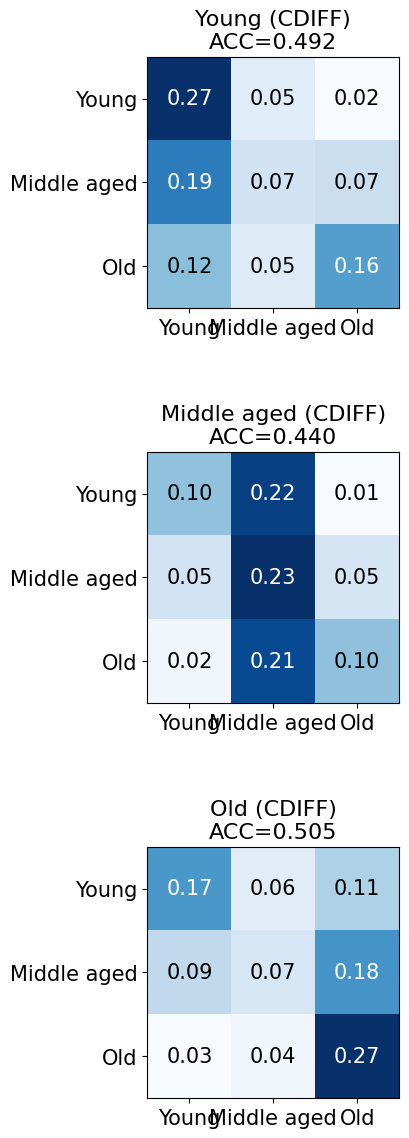

In [25]:
models_to_plot = ["CDIFF"]

n_scenarios = len(all_results[models_to_plot[0]])
n_methods = len(all_results.keys())
fig, axes = plt.subplots(n_scenarios, len(models_to_plot), figsize=(4 * n_methods, 4 * n_scenarios))

cmap = plt.cm.Blues

if len(models_to_plot) == 1:
    axes = axes[:, None]  # keep 2D indexing

for row_idx, scenario in enumerate(all_results[models_to_plot[0]].keys()):
    for col_idx, model_name in enumerate(models_to_plot):
        results = all_results[model_name][scenario]
        ax = axes[row_idx, col_idx]

        im = ax.imshow(results['cm'], interpolation="nearest", cmap=cmap)
        ax.set_title(f"{scenario} ({model_name})\nACC={results['acc']:.3f}", fontsize=16)
        ax.set_xticks(np.arange(len(class_names)))
        ax.set_yticks(np.arange(len(class_names)))
        ax.set_xticklabels(class_names, rotation=0, ha="center", fontsize=15)
        ax.set_yticklabels(class_names, fontsize=15)
        #ax.set_ylabel("True Label")
        #ax.set_xlabel("Predicted Label")

        # annotate cells
        fmt = ".2f"
        thresh = results['cm'].max() / 2.
        for i in range(results['cm'].shape[0]):
            for j in range(results['cm'].shape[1]):
                ax.text(
                    j, i, format(results['cm'][i, j], fmt),
                    ha="center", va="center",
                    color="white" if results['cm'][i, j] > thresh else "black",
                    fontsize = 15
                )

fig.tight_layout()
plt.savefig(f'{TYPE_TO_ANALYSE}_dominant_confusion_matrix.pdf')
plt.show()


In [ ]:
def per_class_accuracy(conf_matrix: np.ndarray) -> np.ndarray:
    """
    Calculate per-class accuracy from a confusion matrix.
    
    Args:
        conf_matrix (np.ndarray): 2D confusion matrix (shape: [n_classes, n_classes])
    
    Returns:
        np.ndarray: 1D array of per-class accuracies
    """
    # Correct predictions are on the diagonal
    correct = np.diag(conf_matrix).astype(float)
    
    # Total instances per class (row sums)
    total = conf_matrix.sum(axis=1).astype(float)
    
    # Avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        per_class_acc = np.divide(correct, total, where=(total != 0))
    
    return per_class_acc


In [ ]:
models_to_plot = models_to_test.copy()
models_to_plot.remove("Baseline")

n_scenarios = len(all_results[models_to_plot[0]])
n_methods = len(all_results.keys())
fig, axes = plt.subplots(n_scenarios, len(models_to_plot), figsize=(4 * n_methods, 4 * n_scenarios))

cmap = plt.cm.Blues

if len(models_to_plot) == 1:
    axes = axes[:, None]  # keep 2D indexing

for row_idx, scenario in enumerate(all_results[models_to_plot[0]].keys()):
    for col_idx, model_name in enumerate(models_to_plot):
        if (row_idx == 0) & (col_idx == 0):
            results = all_results['Baseline']['Baseline']
            ax = axes[row_idx, col_idx]

            accs = per_class_accuracy(results['cm'])
            bars = ax.bar(class_names, accs)
            ax.hlines(1/len(class_names), xmin=-0.5, xmax=2.5, colors='grey', linestyles='dashed', label='chance')

            # Add accuracy values above bars
            for bar, acc in zip(bars, accs):
                height = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height + 0.02,
                    f"{acc:.2f}",
                    ha="center", va="bottom", fontsize=15
                )

            ax.set_title(f"Baseline\nACC={results['acc']:.3f}", fontsize=16)
            ax.set_ylim(0, 1.1)  # extend a bit to fit labels
            ax.set_ylabel("Per-Class Accuracy", fontsize=15)
            ax.tick_params(axis='x', labelsize=15)
            ax.tick_params(axis='y', labelsize=15)

        else:
            results = all_results[model_name][scenario]
            ax = axes[row_idx, col_idx]

            accs = per_class_accuracy(results['cm'])
            bars = ax.bar(class_names, accs)
            ax.hlines(1/len(class_names), xmin=-0.5, xmax=2.5, colors='grey', linestyles='dashed', label='chance')

            # Add accuracy values above bars
            for bar, acc in zip(bars, accs):
                height = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height + 0.02,
                    "0",
                    ha="center", va="bottom", fontsize=15
                )

            ax.set_title(f"PLACEHOLDER\nACC=None", fontsize=16)
            ax.set_ylim(0, 1.1)  # extend a bit to fit labels
            ax.set_ylabel("Per-Class Accuracy", fontsize=15)
            ax.tick_params(axis='x', labelsize=15)
            ax.tick_params(axis='y', labelsize=15)

fig.tight_layout()
plt.savefig(f'{TYPE_TO_ANALYSE}_baseline_acc.pdf')
plt.show()


In [ ]:
models_to_plot = models_to_test.copy()
models_to_plot.remove("Baseline")

n_scenarios = len(all_results[models_to_plot[0]])
n_methods = len(all_results.keys())
fig, axes = plt.subplots(n_scenarios, len(models_to_plot), figsize=(4 * n_methods, 4 * n_scenarios))

cmap = plt.cm.Blues

if len(models_to_plot) == 1:
    axes = axes[:, None]  # keep 2D indexing

for row_idx, scenario in enumerate(all_results[models_to_plot[0]].keys()):
    for col_idx, model_name in enumerate(models_to_plot):
        results = all_results[model_name][scenario]
        ax = axes[row_idx, col_idx]

        accs = per_class_accuracy(results['cm'])
        bars = ax.bar(class_names, accs)
        ax.hlines(1/len(class_names), xmin=-0.5, xmax=2.5, colors='grey', linestyles='dashed', label='chance')

        # Add accuracy values above bars
        for bar, acc in zip(bars, accs):
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.02,
                f"{acc:.2f}",
                ha="center", va="bottom", fontsize=15
            )

        ax.set_title(f"{scenario} ({model_name})\nACC={results['acc']:.3f}", fontsize=16)
        ax.set_ylim(0, 1.1)  # extend a bit to fit labels
        ax.set_ylabel("Per-Class Accuracy", fontsize=15)
        ax.tick_params(axis='x', labelsize=15)
        ax.tick_params(axis='y', labelsize=15)

fig.tight_layout()
plt.savefig(f'{TYPE_TO_ANALYSE}_dominant_per_class_acc.pdf')
plt.show()
